In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'libpysal', 'esda'])

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import os
import glob
import xarray as xr
import rioxarray as rio
import geopandas as gpd

In [43]:
# NO2 VCD GAPFILLED
# Path Data Time Series NO2 VCD
no2_path = r'C:\Users\zaviezra\Documents\UNDIP\TUGAS AKHIR\2.SKRIPSI\1.Processing\2_prevalance\Data\GAPFILL' 
no2_files = glob.glob(os.path.join(no2_path, 'no2_gap_*.tif'))
no2_files.sort()


# Read All NO2 VCD
no2_dataset = []
for file in no2_files:
    data_no2 = rio.open_rasterio(file)
    no2_dataset.append(data_no2)

# Extract Date
dates = [file.split('no2_gap_')[-1].replace('.tif', '') for file in no2_files]
time_no2= pd.to_datetime(dates, format='%Y%m%d')

# Combined Dataset to Xarray
no2_gap = xr.concat(no2_dataset, dim='time').squeeze('band')
no2_gap['time'] = time_no2

# Temporal Aggregation (Monthly Mean)
monthly_mean = no2_gap.groupby('time.month').mean(dim='time')

# View generate metadata associated with the raster file
print("Bounding Box:", monthly_mean.rio.bounds())
print("The crs of your data is:", monthly_mean.rio.crs)
print("The nodatavalue of your data is:", monthly_mean.rio.nodata)
print("The shape of your data is:", monthly_mean.shape)
print("The spatial resolution for your data is:", monthly_mean.rio.resolution())
print("The metadata for your data is:", monthly_mean.attrs)


Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (6, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, 1113.1999999999714)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'no2_vcd_filled'}


# **Hotspot Metode Top 20% Persentil - Monthly**

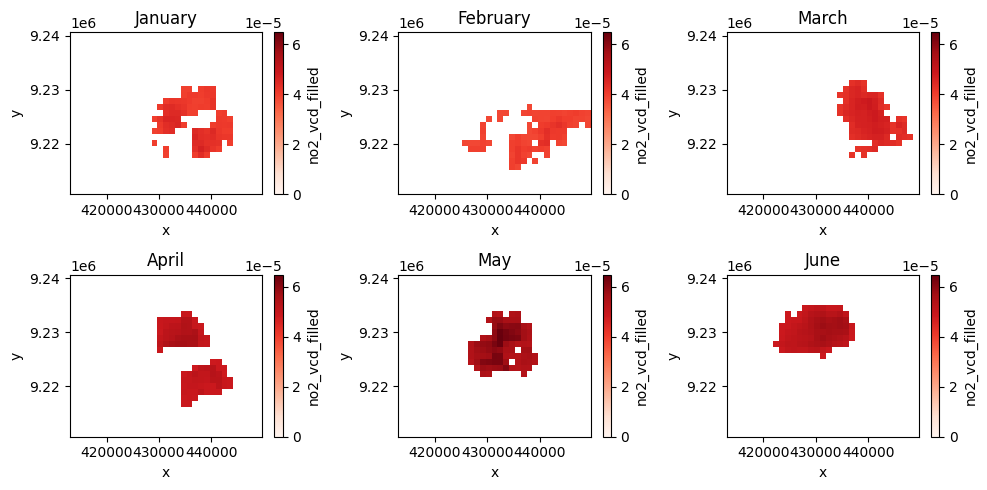

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(10, 5))

month_name = ['January', 'February', 'March', 'April', 'May', 'June']

for i, ax in enumerate(axes.flatten()):
    if i < len(month_name):
        month_i = monthly_mean.sel(month=i+1)

        # threshold P80
        data = month_i.values.flatten()
        data = data[~np.isnan(data)]
        p90 = np.percentile(data, 90)

        hotspot_i = month_i.where(month_i >= p90)

        hotspot_i.plot(
            ax=ax,
            cmap='Reds',
            vmin=0,
            vmax=np.nanmax(monthly_mean.values)
        )

        ax.set_title(month_name[i])
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

Luasan akan konstan karena ini metode persentil. Metode ini berguna untuk analisis distribusi spasial dari NO2. Bisa masukan insight pengaruh-pengaruhnya seperti jalan.

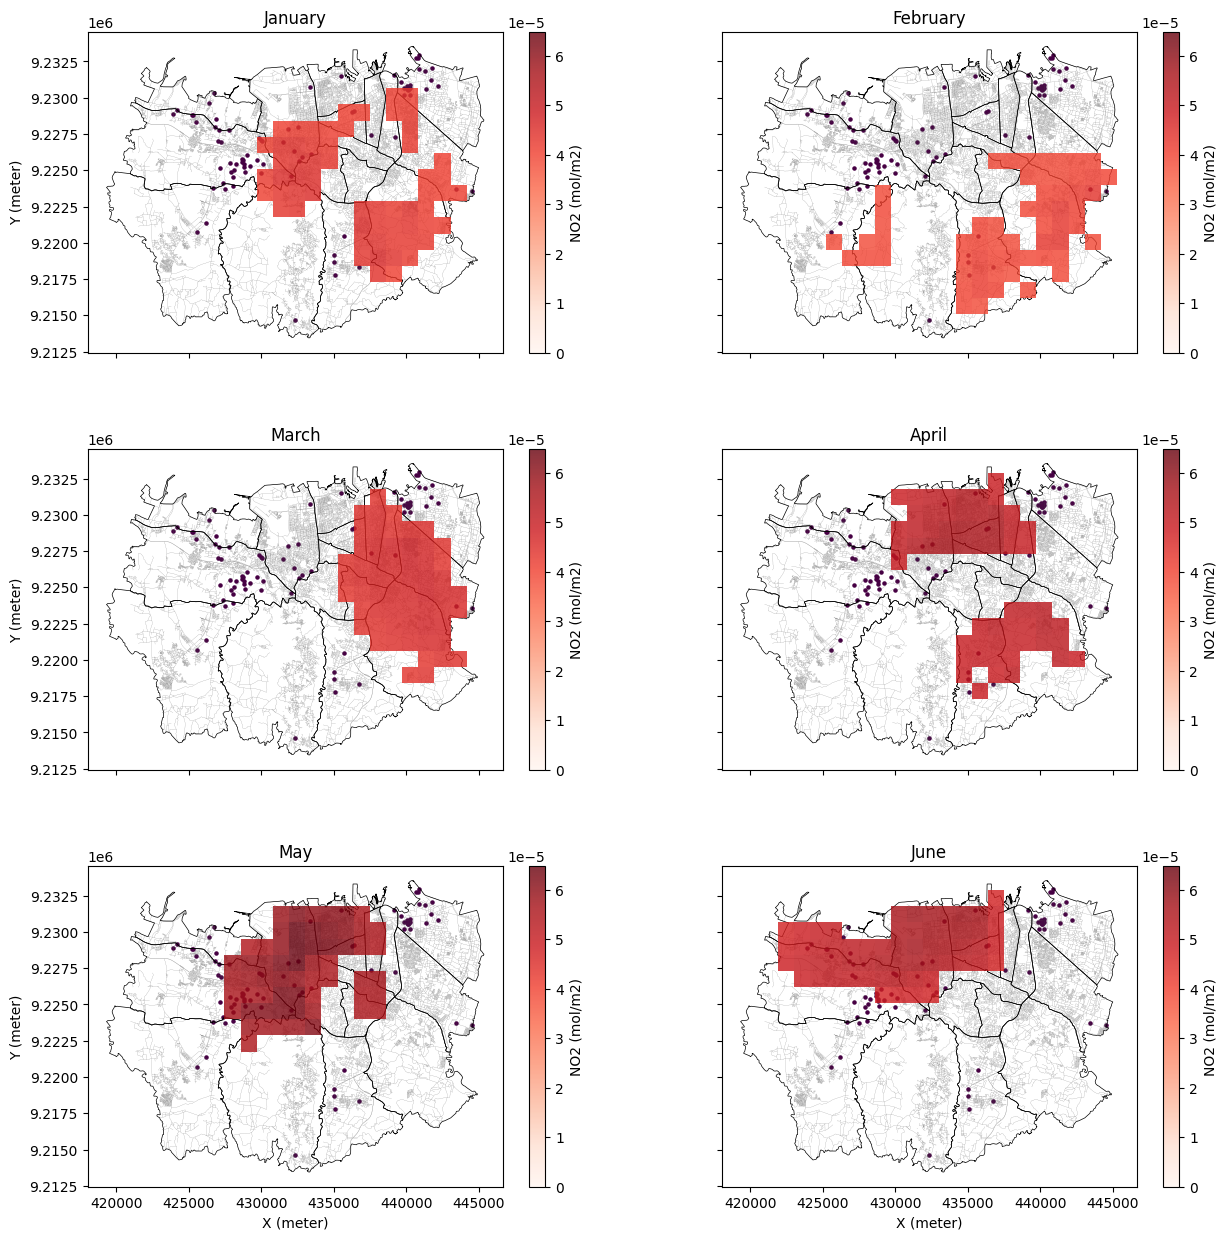

In [67]:
# Import Shapefile Batas Administrasi Semarang
shapefile_batas = r'C:\Users\zaviezra\Documents\UNDIP\TUGAS AKHIR\2.SKRIPSI\1.Processing\2_prevalance\Data\DISTRICT'
shapefile_kec = gpd.read_file(os.path.join(shapefile_batas, 'district_semarang.shp'))

# Import Shapefile Jalan Semarang
shapefile_jalan = r'C:\Users\zaviezra\Documents\UNDIP\TUGAS AKHIR\2.SKRIPSI\1.Processing\2_prevalance\Data\SHP'
shapefile_jln= gpd.read_file(os.path.join(shapefile_jalan, 'JLN_KotaSemarang.shp'))

shapefile_industri = r'C:\Users\zaviezra\Documents\UNDIP\TUGAS AKHIR\2.SKRIPSI\1.Processing\2_prevalance\Data\SHP'
shapefile_ind = gpd.read_file(os.path.join(shapefile_industri, 'industry49s.shp'))
    
shapefile_kec = shapefile_kec.to_crs("EPSG:32749")
shapefile_jln = shapefile_jln.to_crs("EPSG:32749")
shapefile_ind = shapefile_ind.to_crs("EPSG:32749")

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 15), sharex=True, sharey=True)
month_name = ['January', 'February', 'March', 'April', 'May', 'June']
minx, miny, maxx, maxy = shapefile_kec.total_bounds
margin_x = (maxx - minx) * 0.05
margin_y = (maxy - miny) * 0.05 
for i, ax in enumerate(axes.flatten()):
    if i < len(month_name):
        month_i = monthly_mean.sel(month=i+1)
        month_i = month_i.rio.clip(shapefile_kec.geometry, shapefile_kec.crs, drop=True)

        # threshold P80
        data = month_i.values.flatten()
        data = data[~np.isnan(data)]
        p80 = np.percentile(data, 80)

        hotspot_i = month_i.where(month_i >= p80)

        hotspot_i.plot(
            ax=ax,
            cmap='Reds',
            vmin=0,
            vmax=np.nanmax(monthly_mean.values),
            alpha=0.8,
            zorder=4,
            cbar_kwargs={'label': 'NO2 (mol/m2)'}
        )

        shapefile_kec.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5, zorder=3)
        shapefile_jln.plot(ax=ax, color="#505050", linewidth=0.1, zorder=2)
        shapefile_ind.plot(ax=ax, color="#460043", markersize=5, zorder=1)    
        ax.set_title(month_name[i])

        ax.set_xlabel("X (meter)")
        ax.set_ylabel("Y (meter)")
        ax.label_outer()
        ax.set_xlim(minx - margin_x, maxx + margin_x)
        ax.set_ylim(miny - margin_y, maxy + margin_y)
        ax.set_aspect('equal')
    else:
        ax.axis('on')

plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.show()